# Problem Statement 1 :

An analytics company has been tasked with the crucial job of finding out what factors affect a startup company and if it will be profitable or not. For this, they have collected some historical data and would like to apply multilinear regression to derive brief insights into their data. Predict profit, given different attributes for various startup companies.

# Business Objective:--->

Determine Key Factors Affecting Profitability

Predict Profitability-->develop a model to predict the profit of a startup based on different input features

Help startups understand where to invest more (e.g., R&D, Administration, or Marketing) for better profitability.

Support Decision Making--> Provide insights to investors, entrepreneurs, and business owners for strategic planning.

# Constraints:--->

Multicollinearity Issue: If two or more input features are highly correlated, one of them should be dropped to avoid redundancy and overfitting.

Assumptions of Multiple Linear Regression:
Linear relationship between independent and dependent variables.
No autocorrelation in residuals.
Homoscedasticity (constant variance of errors).
Normal distribution of residuals.

Data quality

# Dataset description:--->

dataset contains information about different startup companies, their investments in various areas, and their corresponding profits.

Columns explanation-->

R&D Spend: Represents the amount spent on research and development (R&D).

Administration: Represents expenses related to administrative activities

Marketing Spend: Represents the amount spent on marketing and advertising.

State: Represents the location of the startup

Profit(Target Variable):Represents the company's profit.

In [1]:
#import the required files
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
#load the dataset 
data=pd.read_csv("F:/Data science/Assignments/last_ass/multilinear_dataset/Startups.csv")

In [5]:
# Check for missing values
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [7]:
# check the shape of dataset 
data.shape

(50, 5)

In [3]:
#describe the data
data.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [4]:
#print 1st 5 rows for understanding the dataset
data.head(5)

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [8]:
# ---  Data Pre-processing ---
# Encode categorical variables
encoder = OneHotEncoder(drop='first', sparse=False)
state_encoded = encoder.fit_transform(data[['State']])
state_df = pd.DataFrame(state_encoded, columns=encoder.get_feature_names_out(['State']))
data = pd.concat([data.drop(columns=['State']), state_df], axis=1)

In [9]:
# Checking for missing values
data.isnull().sum()

R&D Spend          0
Administration     0
Marketing Spend    0
Profit             0
State_Florida      0
State_New York     0
dtype: int64

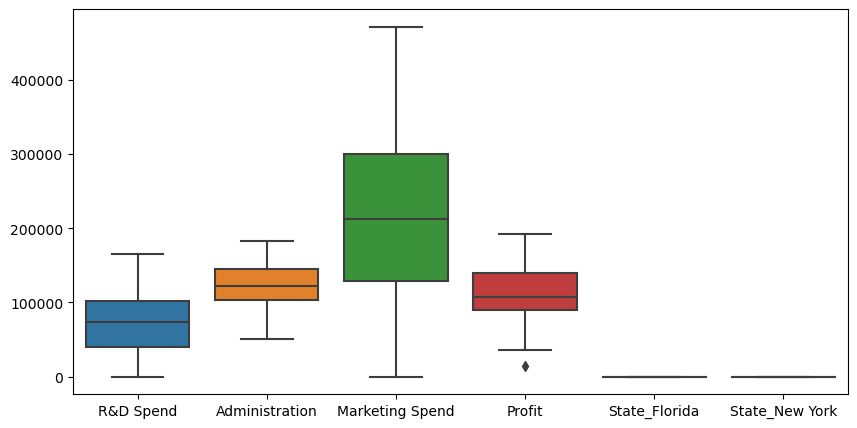

In [10]:
# ---  Outlier Treatment ---
plt.figure(figsize=(10, 5))
sns.boxplot(data=data)
plt.show()  # Check for outliers visually

In [11]:
# Using IQR method to remove outliers
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

In [12]:
# Define upper and lower bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [13]:
# Removing outliers
data = data[~((data < lower_bound) | (data > upper_bound)).any(axis=1)]

In [14]:
# ---  Exploratory Data Analysis (EDA) ---
print("\nSummary Statistics:\n", data.describe())


Summary Statistics:
            R&D Spend  Administration  Marketing Spend         Profit  \
count      49.000000       49.000000        49.000000      49.000000   
mean    75226.138367   121433.636327    214409.833265  113998.991020   
std     45115.141560    28301.008988    121168.170072   38171.246893   
min         0.000000    51283.140000         0.000000   35673.410000   
25%     44069.950000   103057.490000    134050.070000   90708.190000   
50%     73994.560000   122782.750000    214634.810000  108552.040000   
75%    101913.080000   145077.580000    299737.290000  141585.520000   
max    165349.200000   182645.560000    471784.100000  192261.830000   

       State_Florida  State_New York  
count      49.000000       49.000000  
mean        0.326531        0.346939  
std         0.473804        0.480929  
min         0.000000        0.000000  
25%         0.000000        0.000000  
50%         0.000000        0.000000  
75%         1.000000        1.000000  
max         1.000

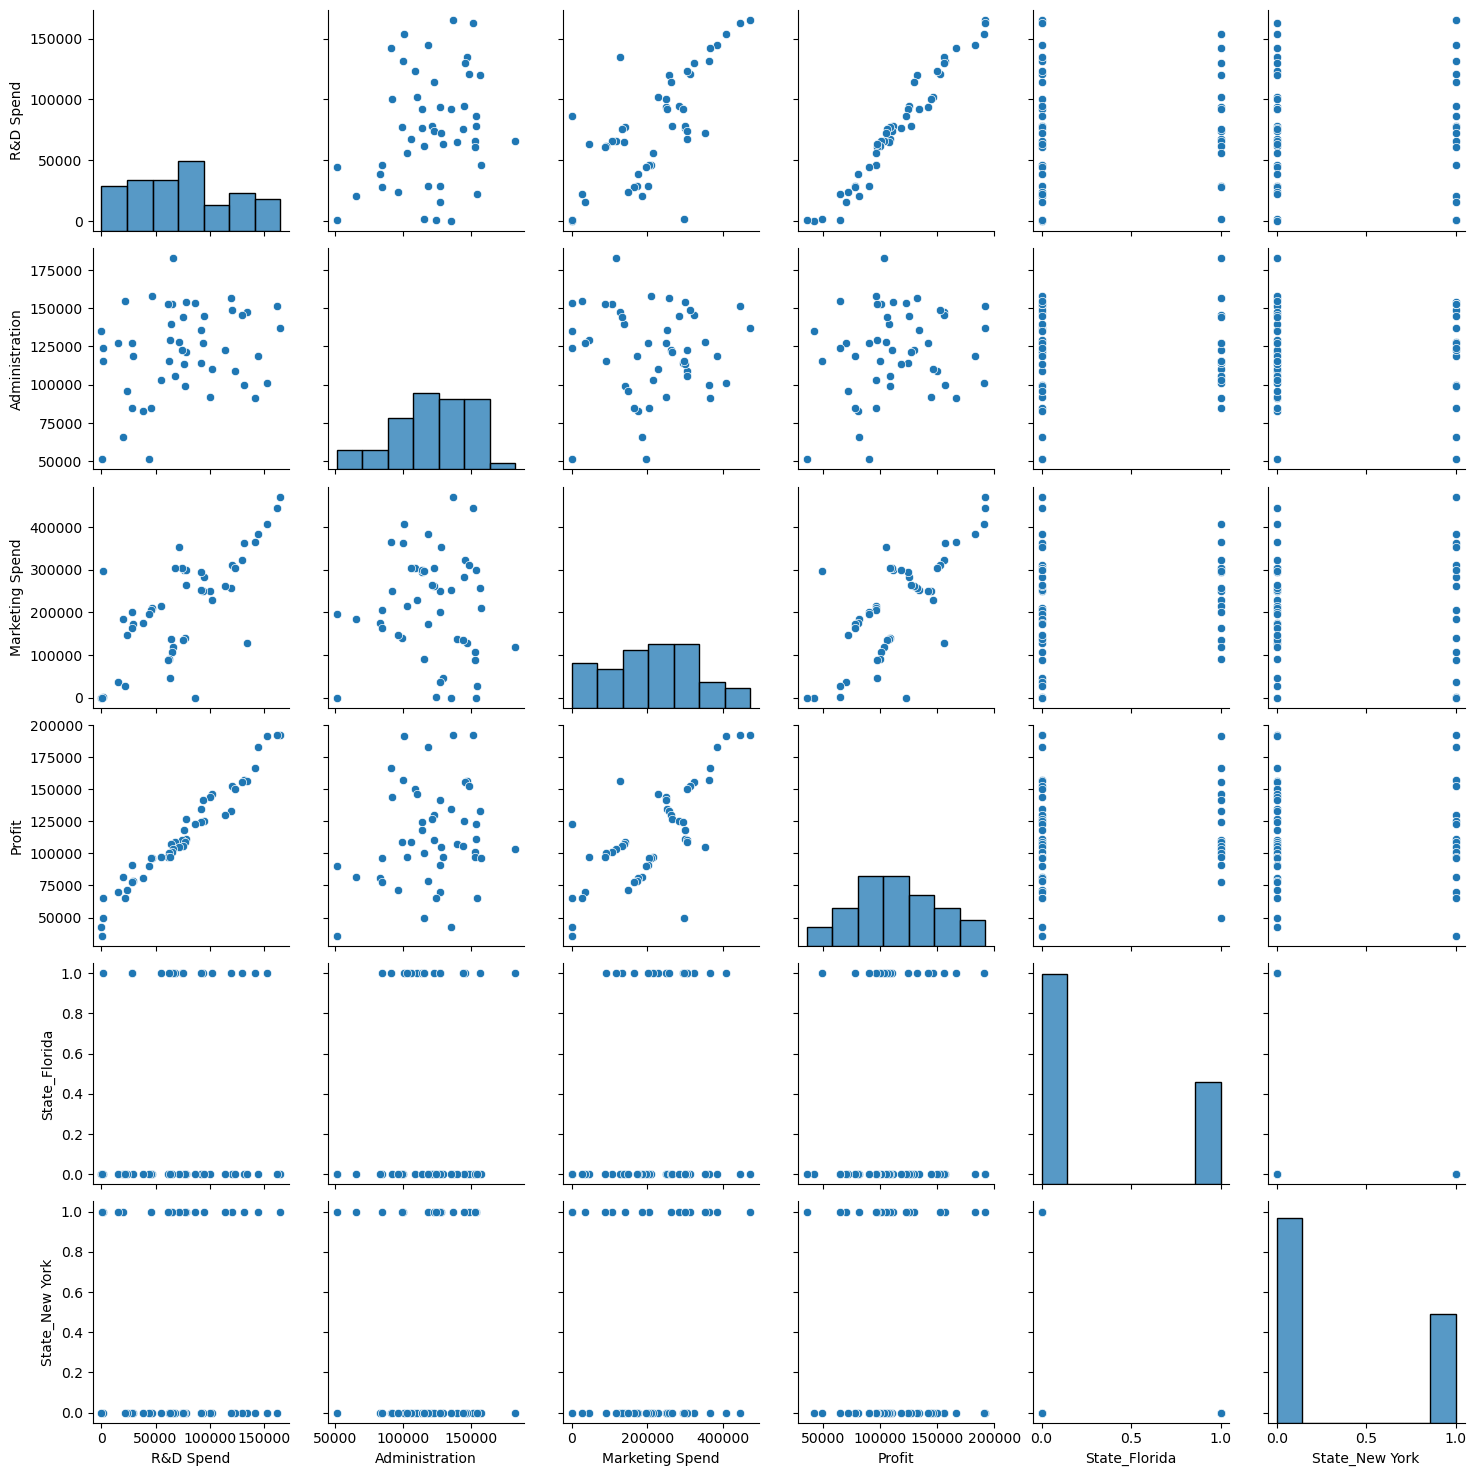

In [15]:
# Univariate Analysis
sns.pairplot(data)
plt.show()

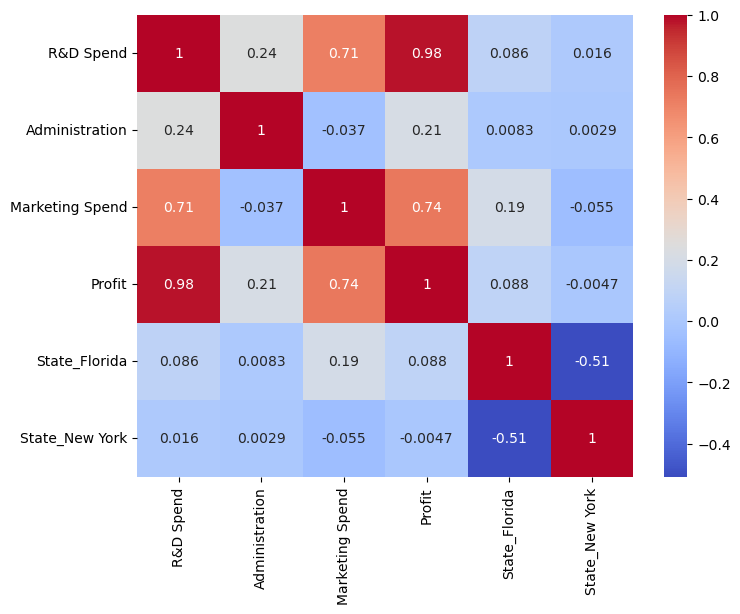

In [16]:
# Bivariate Analysis
plt.figure(figsize=(8, 6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.show()

In [17]:
# ---  Model Building ---
X = data.drop(columns=['Profit'])
y = data['Profit']

In [18]:
# Checking for multicollinearity using VIF
X_with_const = sm.add_constant(X)
VIF_data = pd.DataFrame()
VIF_data['Feature'] = X_with_const.columns
VIF_data['VIF'] = [variance_inflation_factor(X_with_const.values, i) for i in range(X_with_const.shape[1])]
print("\nVariance Inflation Factor (VIF):\n", VIF_data)


Variance Inflation Factor (VIF):
            Feature        VIF
0            const  26.483429
1        R&D Spend   2.400821
2   Administration   1.177936
3  Marketing Spend   2.324983
4    State_Florida   1.401124
5   State_New York   1.353517


In [19]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
# Standardizing Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
# --- Build and Evaluate Model ---
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

In [22]:
# Model Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse}, R-Squared: {r2}")

RMSE: 8102.917608199522, R-Squared: 0.9190784410372372


eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1


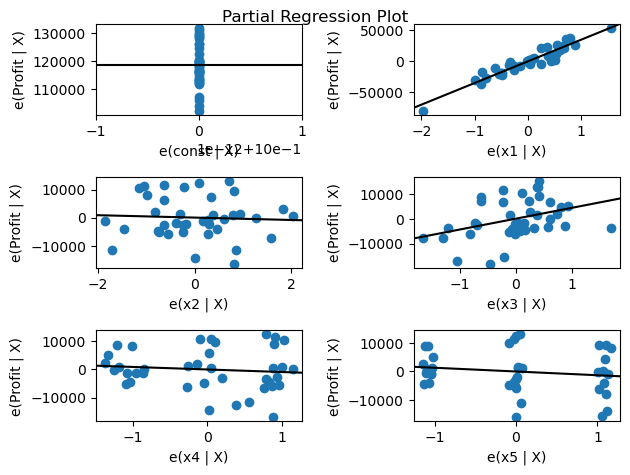

In [23]:
# --- Model Diagnostic Plots ---
sm_model = sm.OLS(y_train, sm.add_constant(X_train_scaled)).fit()
fig = sm.graphics.plot_partregress_grid(sm_model)
plt.show()

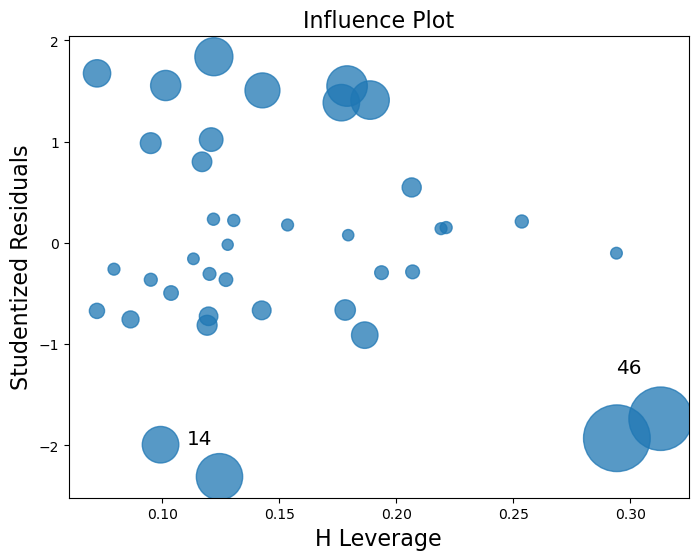

In [24]:
# Influence Plot
fig, ax = plt.subplots(figsize=(8,6))
sm.graphics.influence_plot(sm_model, ax=ax)
plt.show()

In [25]:
#---- Model Tuning ---
# ---  Business Impact ---
print("\nBusiness Impact:\n")
print("1. Helps startups allocate budgets effectively.")
print("2. Identifies key factors driving profitability.")
print("3. Provides a data-driven approach for investment decisions.")


Business Impact:

1. Helps startups allocate budgets effectively.
2. Identifies key factors driving profitability.
3. Provides a data-driven approach for investment decisions.


Root Mean Squared Error (RMSE): 8102.92

R-Squared (R²): 0.9191 (~91.9%)

Interpretation: 

R² = 91.9%: The model explains 91.9% of the variance in Profit, indicating a strong predictive ability.

RMSE = 8102.92: The model's average prediction error is around $8,102, which is reasonable given the scale of Profit values.

# Problem statement  2--->

An online car sales platform would like to improve its customer base and their experience by providing them an easy way to buy and sell cars. For this, they would like an automated model which can predict the price of the car once the user inputs the required factors. Help the business achieve their objective by applying multilinear regression on the given dataset. Please use the below columns for the analysis purpose: price, age_08_04, KM, HP, cc, Doors, Gears, Quarterly_Tax, and Weight.

# Business Objective-->

Provide an automated pricing model for users to estimate car prices based on input features.

Improve customer buying and selling experience by offering a transparent pricing mechanism.

Identify which factors influence car prices the most, helping businesses optimize pricing strategies.

# Constraints-->

Multicollinearity: If input features are highly correlated, it may affect model accuracy.

Interpretability: The model should be explainable to gain business trust.

In [3]:
# Importing Required Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

In [8]:
# Load the dataset
df = pd.read_csv("ToyotaCorolla.csv", encoding="latin1")

In [11]:
# Display the first few rows
df.head(4)

,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Central_Lock,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,...,1,1,1,0,0,0,1,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,...,1,0,1,0,0,0,1,0,0,0
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,...,0,0,1,0,0,0,1,0,0,0
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,...,0,0,1,0,0,0,1,0,0,0


In [12]:
# --- Data Preprocessing ---
# Selecting relevant columns for analysis
columns = ['Price', 'Age_08_04', 'KM', 'HP', 'cc', 'Doors', 'Gears', 'Quarterly_Tax', 'Weight']
df = df[columns]

In [13]:
# Check for missing values
print("Missing Values:", df.isnull().sum())

Missing Values: Price            0
Age_08_04        0
KM               0
HP               0
cc               0
Doors            0
Gears            0
Quarterly_Tax    0
Weight           0
dtype: int64


In [14]:
# Handling missing values (if any) - Impute with median
df.fillna(df.median(), inplace=True)

In [15]:
# Convert categorical variable 'Doors' into numerical (some datasets may have it as an object)
df['Doors'] = pd.to_numeric(df['Doors'], errors='coerce')
df['Doors'].fillna(df['Doors'].median(), inplace=True)

In [16]:
# --- Exploratory Data Analysis (EDA) ---
# Summary Statistics
print("Summary Statistics:", df.describe())


Summary Statistics:               Price    Age_08_04             KM           HP           cc  \
count   1436.000000  1436.000000    1436.000000  1436.000000   1436.00000   
mean   10730.824513    55.947075   68533.259749   101.502089   1576.85585   
std     3626.964585    18.599988   37506.448872    14.981080    424.38677   
min     4350.000000     1.000000       1.000000    69.000000   1300.00000   
25%     8450.000000    44.000000   43000.000000    90.000000   1400.00000   
50%     9900.000000    61.000000   63389.500000   110.000000   1600.00000   
75%    11950.000000    70.000000   87020.750000   110.000000   1600.00000   
max    32500.000000    80.000000  243000.000000   192.000000  16000.00000   

             Doors        Gears  Quarterly_Tax      Weight  
count  1436.000000  1436.000000    1436.000000  1436.00000  
mean      4.033426     5.026462      87.122563  1072.45961  
std       0.952677     0.188510      41.128611    52.64112  
min       2.000000     3.000000      19.00

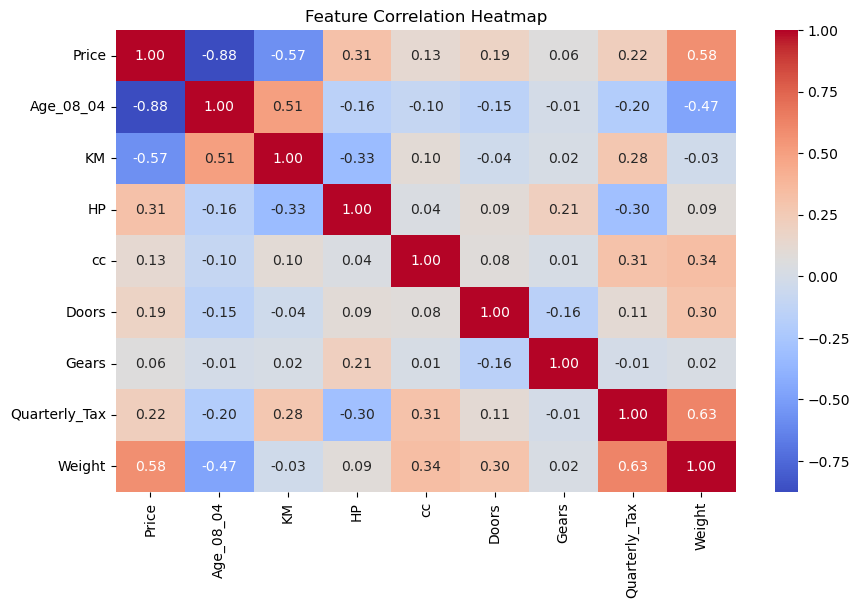

In [17]:
# Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

In [18]:
# ---  Checking for Multicollinearity using VIF ---
X = df.drop(columns=['Price'])
X = sm.add_constant(X)  # Adding intercept term
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("\nVariance Inflation Factor (VIF):\n", vif_data)


Variance Inflation Factor (VIF):
          Feature          VIF
0          const  1587.223011
1      Age_08_04     1.884620
2             KM     1.756905
3             HP     1.419422
4             cc     1.163894
5          Doors     1.156575
6          Gears     1.098723
7  Quarterly_Tax     2.311431
8         Weight     2.516420


In [19]:
# Dropping features with high VIF (if necessary)
# Example: If cc has a very high VIF (>10), we might drop it

# ---  Model Building ---
# Splitting data into train and test sets (80% train, 20% test)
X = df.drop(columns=['Price'])
y = df['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
# Standardizing numerical features 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
# Training the Multiple Linear Regression Model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [22]:
# Model Coefficients
print("Model Coefficients:", dict(zip(X.columns, model.coef_)))

Model Coefficients: {'Age_08_04': -2245.938818777426, 'KM': -782.3427590618116, 'HP': 423.2676634957437, 'cc': -50.58965339146193, 'Doors': 5.310501647703075, 'Gears': 112.2743993263919, 'Quarterly_Tax': 59.69402699147465, 'Weight': 985.0806795549593}


In [23]:
# ---  Model Evaluation ---
y_pred = model.predict(X_test_scaled)

In [24]:
# Calculate R-Squared and RMSE
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

In [25]:
print("\nModel Evaluation:")
print(f"R-Squared: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")


Model Evaluation:
R-Squared: 0.8538
RMSE: 1396.5117


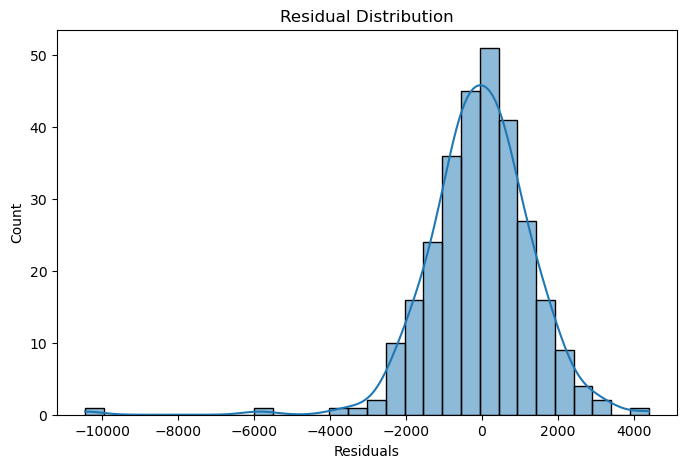

In [26]:
# --- Residual Analysis ---
residuals = y_test - y_pred
plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=30, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residuals")
plt.show()

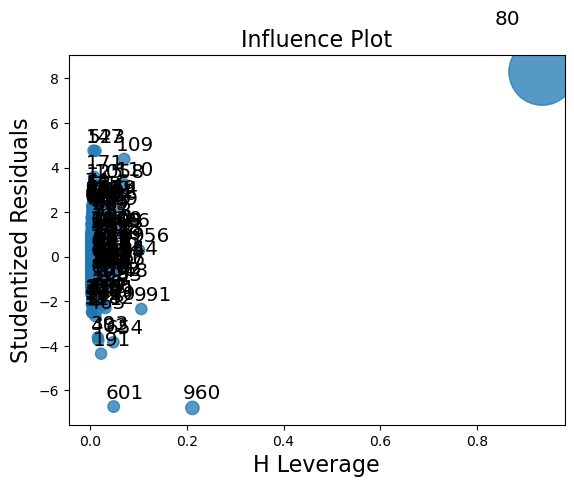

In [27]:
# --- Influence Index Plot (Checking for Influential Points) ---
model_stats = sm.OLS(y_train, sm.add_constant(X_train_scaled)).fit()
sm.graphics.influence_plot(model_stats, criterion="cooks")
plt.show()

Key Insights --->

Feature Selection: Uses essential car attributes affecting price.

Multicollinearity Check: VIF is used to detect highly correlated variables.

Model Evaluation: R² and RMSE give an indication of how well the model fits.

Residual Analysis: Ensures no major outliers are affecting predictions.

Influence Plot: Detects points that might overly influence the model.

Model Evaluation:
R-Squared: 0.8538
RMSE: 1396.5117

This means 85% of the variation in car prices is explained by the model, which is quite good! Lower RMSE means better prediction accuracy.


# Problem Statement 3: 
With the growing consumption of avocados in the USA, a freelance company would like to do some analysis on the patterns of consumption in different cities and would like to come up with a prediction model for the price of avocados. For this to be implemented, build a prediction model using multilinear regression and provide your insights on it.

# Business Objectives-->

The goal of this analysis is to predict the price of avocados based on various features like total volume, type of avocado, region, and year. This will help farmers, retailers, and distributors optimize pricing strategies, manage supply chains, and increase profitability.

# Constraints-->

Data Availability & Quality -–> Historical data may have missing values, inconsistencies, or errors that can affect model accuracy.

Seasonality Effects –-> Avocado prices fluctuate based on seasons, requiring time-based adjustments.

model interpretability-->The model should be easy to interpret so stakeholders (retailers, farmers) can make informed decisions

In [28]:
#import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [29]:
# Load dataset
df = pd.read_csv("Avacado_Price.csv")

In [30]:
# Drop irrelevant columns if needed (e.g., 'type' isn't useful for numeric regression)
df = df.drop(columns=["type"]) 

In [31]:
# Encode categorical variable (region)
label_encoder = LabelEncoder()
df["region"] = label_encoder.fit_transform(df["region"])

In [32]:
# Feature Selection
X = df[["Total_Volume", "tot_ava1", "tot_ava2", "tot_ava3", "Total_Bags", "Small_Bags", "Large_Bags", "XLarge Bags", "year", "region"]]
y = df["AveragePrice"]

In [33]:
# Standardize Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [34]:
# Summary Statistics
df.describe()

,AveragePrice,Total_Volume,tot_ava1,tot_ava2,tot_ava3,Total_Bags,Small_Bags,Large_Bags,XLarge Bags,year,region
count,18249.000000,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,18249.000000,18249.000000,18249.000000
mean,1.405978,8.506440e+05,2.930084e+05,2.951546e+05,2.283974e+04,2.396392e+05,1.821947e+05,5.433809e+04,3106.426507,2016.147899,26.495644
std,0.402677,3.453545e+06,1.264989e+06,1.204120e+06,1.074641e+05,9.862424e+05,7.461785e+05,2.439660e+05,17692.894652,0.939938,15.583788
min,0.440000,8.456000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,2015.000000,0.000000
25%,1.100000,1.083858e+04,8.540700e+02,3.008780e+03,0.000000e+00,5.088640e+03,2.849420e+03,1.274700e+02,0.000000,2015.000000,13.000000
50%,1.370000,1.073768e+05,8.645300e+03,2.906102e+04,1.849900e+02,3.974383e+04,2.636282e+04,2.647710e+03,0.000000,2016.000000,26.000000
75%,1.660000,4.329623e+05,1.110202e+05,1.502069e+05,6.243420e+03,1.107834e+05,8.333767e+04,2.202925e+04,132.500000,2017.000000,40.000000
max,3.250000,6.250565e+07,2.274362e+07,2.047057e+07,2.546439e+06,1.937313e+07,1.338459e+07,5.719097e+06,551693.650000,2018.000000,53.000000


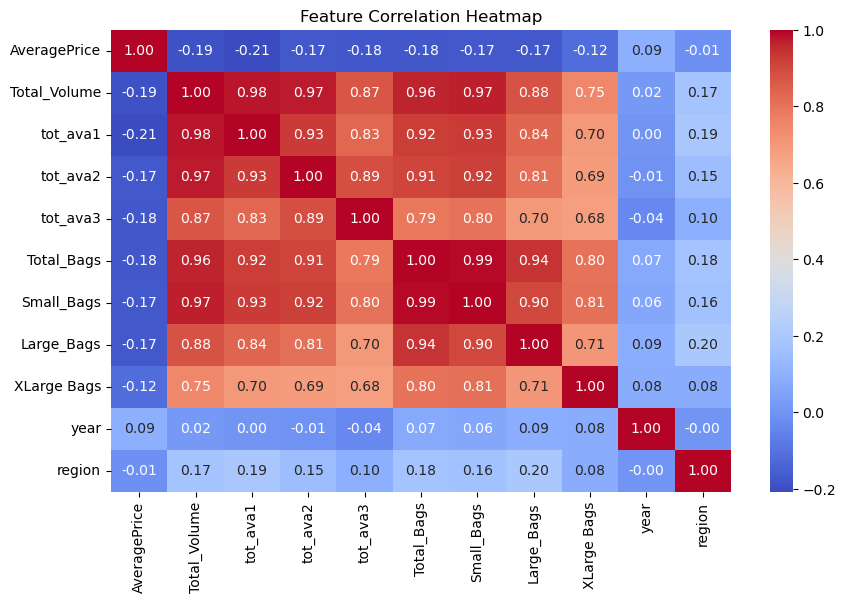

In [35]:
# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

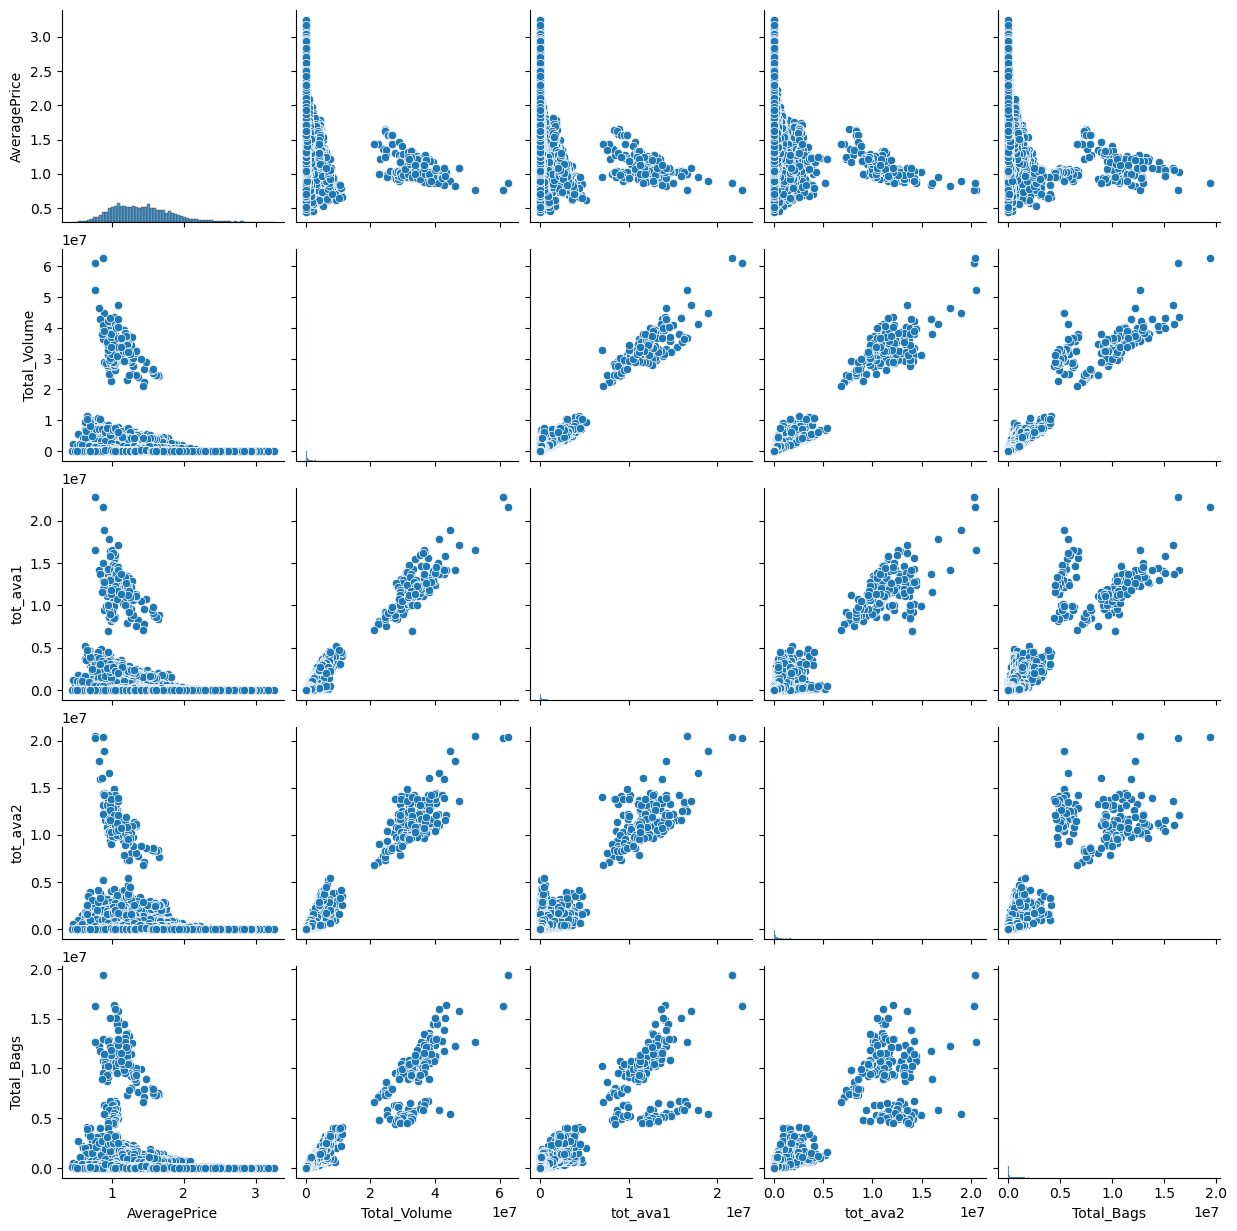

In [36]:
# Pairplot for Relationship Visualization
sns.pairplot(df[["AveragePrice", "Total_Volume", "tot_ava1", "tot_ava2", "Total_Bags"]])
plt.show()

In [37]:
# Calculate Variance Inflation Factor (VIF)
X_const = sm.add_constant(X_scaled)
vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X_const, i+1) for i in range(len(X.columns))]  # Skip intercept
print(vif)

        Feature           VIF
0  Total_Volume  4.916140e+09
1      tot_ava1  6.595747e+08
2      tot_ava2  5.976291e+08
3      tot_ava3  4.760260e+06
4    Total_Bags  2.370316e+14
5    Small_Bags  1.364727e+14
6    Large_Bags  1.448103e+13
7   XLarge Bags  7.620497e+10
8          year  1.047906e+00
9        region  1.067969e+00


VIF < 5 is acceptable (no multicollinearity). If VIF > 10, drop or transform that feature.

In [38]:
# Split Data into Training & Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [39]:
# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [40]:
# Predictions
y_pred = model.predict(X_test)

In [41]:
# Calculate RMSE & R-Squared
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [42]:
print(f"RMSE: {rmse:.2f}")
print(f"R-Squared: {r2:.4f}")

RMSE: 0.39
R-Squared: 0.0554


Observations-->High R-square and Low RMSE mean good model performance

In [43]:
# Fit model with StatsModels for detailed analysis
X_const = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_const).fit()
print(ols_model.summary())  # Check p-values & significance

                            OLS Regression Results                            
Dep. Variable:           AveragePrice   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.062
Method:                 Least Squares   F-statistic:                     96.84
Date:                Fri, 28 Feb 2025   Prob (F-statistic):          4.47e-195
Time:                        07:03:24   Log-Likelihood:                -6982.2
No. Observations:               14599   AIC:                         1.399e+04
Df Residuals:                   14588   BIC:                         1.407e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.4049      0.003    434.655      0.0

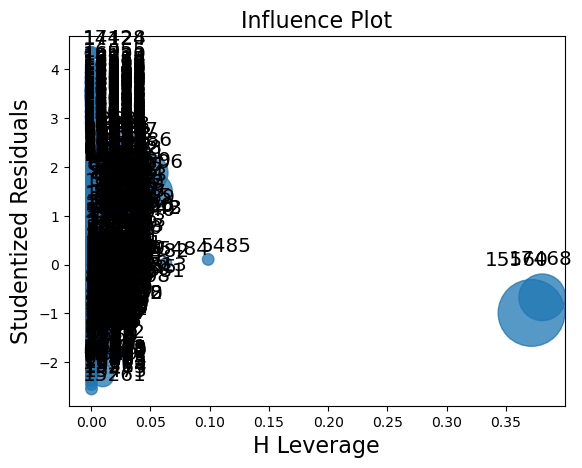

In [44]:
# Influence Index Plot (Identifies outliers)
sm.graphics.influence_plot(ols_model, figsize=(10,6))
plt.show()

too many points have high influence, consider a different model (e.g., robust regression).

Result Analysis-->

Poor Model Fit (Low R-Squared)

The R² value is 0.0554, meaning the model explains only 5.54% of the variance in avocado prices.
This suggests that the features used are weak predictors of price, and additional relevant factors should be considered.

High RMSE (0.39)

An RMSE of 0.39 indicates that the model’s predictions deviate significantly from actual values.
While the magnitude of the RMSE depends on the price range, it shows that the model lacks precision.